# Evaluation of the Surfeit class

This notebook demonstrates the simplified `Surfeit` API.

The new class is intentionally string-based: it does not serialize scikit-learn models by itself. Instead, the user supplies a model description string and `Surfeit` estimates how much unnecessary structure appears to be present in that description.


In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.pylab import rcParams

from sklearn.datasets import make_blobs
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.tree import DecisionTreeClassifier, export_text

from mnplib.inaccuracy import Inaccuracy
from mnplib.surfeit import Surfeit, surfeit_score


In [2]:
rcParams["figure.figsize"] = 10, 5
rng = np.random.default_rng(42)

## 1. Basic string-based usage

The simplest use case is to fit the target representation and then evaluate a model description string.


In [3]:
y = np.array([0, 0, 1, 1, 0, 1])

model_description = """def model(x):
    return int(x > 0)
"""

sft = Surfeit(y_type="categorical")
sft.fit_y(y)

sft.surfeit_string(model_description)

0.8333333333333334

The same computation can be performed with the functional interface.


In [4]:
surfeit_score(model_description, y, y_type="categorical")

0.8333333333333334

## 2. Surfeit and redundant descriptions

Surfeit is sensitive to redundancy in the model description. The following two descriptions express the same simple rule, but the second one contains repeated, unnecessary structure.


In [5]:
compact_rule = """def model(x):
    return int(x > 0)
"""

redundant_rule = """def model(x):
    # Repeated equivalent tests.
    if x > 0:
        result = 1
    else:
        result = 0

    if x > 0:
        result_again = 1
    else:
        result_again = 0

    if x > 0:
        result_third_time = 1
    else:
        result_third_time = 0

    return result
"""

rows = []
for name, description in [
    ("Compact rule", compact_rule),
    ("Redundant rule", redundant_rule),
]:
    rows.append(
        {
            "description": name,
            "length": len(description.encode("utf-8")),
            "surfeit": sft.surfeit_string(description),
        }
    )

pd.DataFrame(rows)

,description,length,surfeit
0,Compact rule,36,0.833333
1,Redundant rule,288,0.979167


The redundant description is longer and more compressible. This is precisely the kind of unnecessary descriptive structure that surfeit is intended to expose.


## 3. Surfeit and polynomial overfitting

In this example, we approximate a noisy sinusoidal curve with polynomial models of increasing degree.

The notebook defines its own external serializer for linear models. This keeps serialization outside the `Surfeit` class, which is the intended design of the simplified implementation.


In [6]:
def linear_model_to_string(model, *, name="model") -> str:
    """Serialize a fitted linear model as a compact Python-like expression."""
    coefs = np.ravel(model.coef_)
    terms = [f"{coef:.6g} * x{i}" for i, coef in enumerate(coefs)]
    expression = " + ".join(terms) if terms else "0"
    expression = f"{model.intercept_:.6g} + " + expression

    return f"""def {name}(x):
    return {expression}
"""


def polynomial_model_to_string(pipeline, degree: int) -> str:
    """Serialize a fitted polynomial regression pipeline."""
    model = pipeline.named_steps["linearregression"]
    description = linear_model_to_string(model, name=f"polynomial_degree_{degree}")
    return "# PolynomialFeatures are assumed to be applied before this function.\n" + description


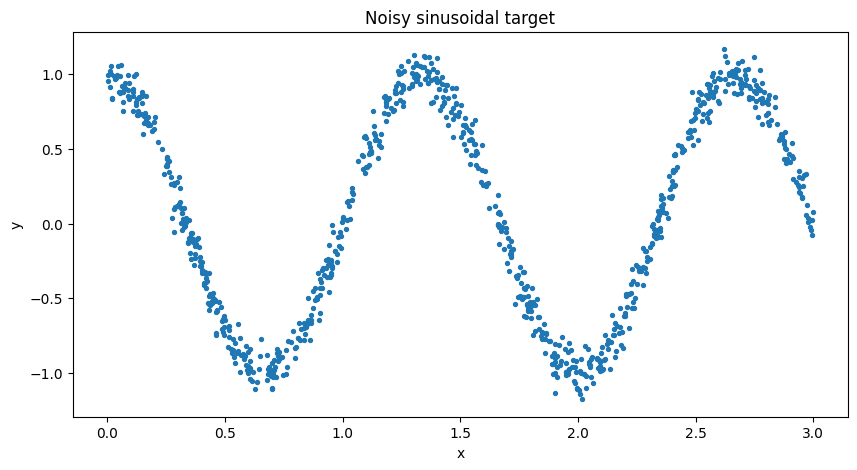

In [7]:
n_samples = 900
degrees = np.arange(1, 16)

X = np.sort(rng.random(n_samples) * 3)
noise = 0.08 * rng.normal(size=n_samples)
y = np.cos(1.5 * np.pi * X) + noise

plt.scatter(X, y, s=8)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Noisy sinusoidal target")
plt.show()

In [8]:
inacc = Inaccuracy(y_type="numeric", n_bins="auto")
sft = Surfeit(y_type="numeric", n_bins="auto")

inaccuracies = []
surfeits = []
description_lengths = []

for degree in degrees:
    model = make_pipeline(
        PolynomialFeatures(degree=degree, include_bias=False),
        LinearRegression(),
    )
    model.fit(X[:, np.newaxis], y)

    predictions = model.predict(X[:, np.newaxis])
    description = polynomial_model_to_string(model, degree=degree)

    inacc.fit_y(y)
    sft.fit_y(y)

    inaccuracies.append(inacc.inaccuracy_predictions(predictions))
    surfeits.append(sft.surfeit_string(description))
    description_lengths.append(len(description.encode("utf-8")))

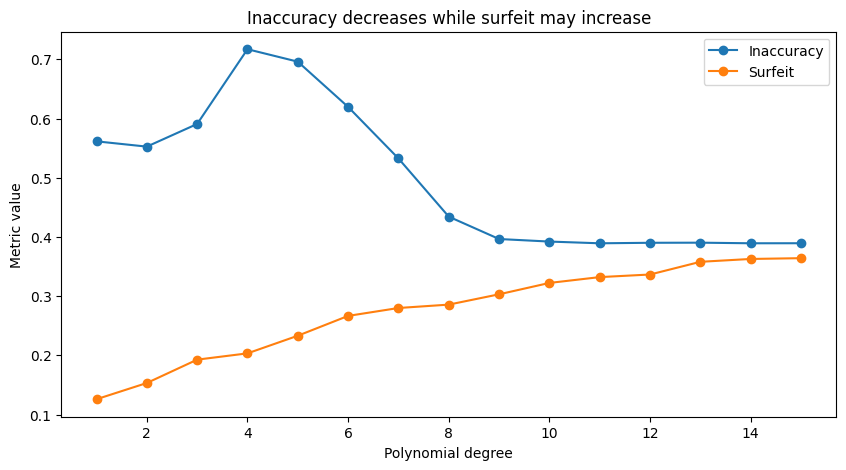

In [9]:
plt.plot(degrees, inaccuracies, marker="o", label="Inaccuracy")
plt.plot(degrees, surfeits, marker="o", label="Surfeit")
plt.xlabel("Polynomial degree")
plt.ylabel("Metric value")
plt.title("Inaccuracy decreases while surfeit may increase")
plt.legend(loc="best")
plt.show()

In [10]:
pd.DataFrame(
    {
        "degree": degrees,
        "description_length": description_lengths,
        "inaccuracy": inaccuracies,
        "surfeit": surfeits,
    }
)

,degree,description_length,inaccuracy,surfeit
0,1,135,0.561480,0.125926
1,2,150,0.552560,0.153333
2,3,166,0.590808,0.192771
3,4,177,0.717070,0.203390
4,5,193,0.696034,0.233161
5,6,210,0.619584,0.266667
6,7,225,0.532540,0.280000
7,8,238,0.434264,0.285714
8,9,254,0.396500,0.303150
9,10,273,0.392207,0.322344


The usual error of a polynomial model tends to decrease as the degree grows. Surfeit adds a complementary view: it measures whether the description is becoming unnecessarily long or redundant relative to the target representation.


## 4. External serialization: decision tree versus neural network

The old `Surfeit` class tried to serialize models internally. The new class deliberately avoids that. The following helper functions live in the notebook and convert fitted models into simple strings only for demonstration purposes.


In [11]:
def decision_tree_to_string(model, feature_names=None) -> str:
    """Serialize a fitted decision tree using scikit-learn's text exporter."""
    if feature_names is None:
        feature_names = [f"x{i}" for i in range(model.n_features_in_)]
    return export_text(model, feature_names=feature_names)


def mlp_to_string(model) -> str:
    """Serialize a fitted MLP by recording architecture, weights, and biases."""
    lines = ["MLPClassifier"]
    lines.append(f"hidden_layer_sizes={model.hidden_layer_sizes}")
    lines.append(f"activation={model.activation}")
    lines.append(f"solver={model.solver}")

    for layer_index, weights in enumerate(model.coefs_):
        lines.append(f"weights_layer_{layer_index}={np.array2string(weights, precision=4, separator=',')}")

    for layer_index, biases in enumerate(model.intercepts_):
        lines.append(f"biases_layer_{layer_index}={np.array2string(biases, precision=4, separator=',')}")

    return "\n".join(lines)

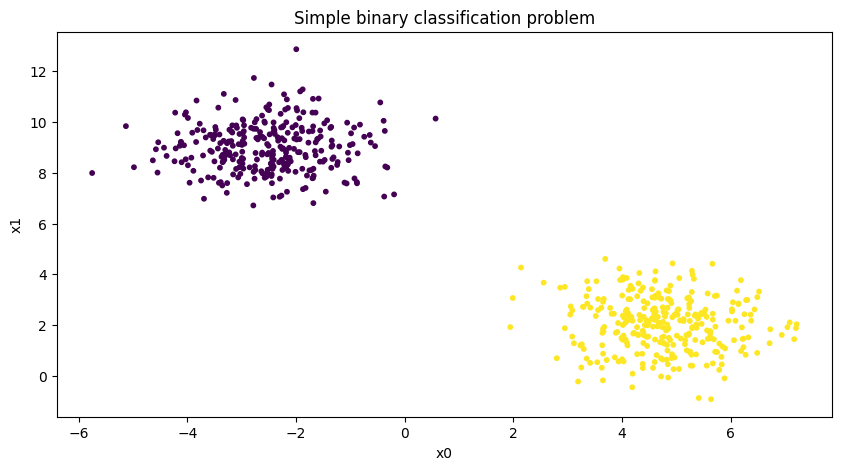

In [12]:
X, y = make_blobs(
    n_samples=600,
    centers=2,
    n_features=2,
    cluster_std=1.0,
    random_state=42,
)

plt.scatter(X[:, 0], X[:, 1], c=y, s=10)
plt.xlabel("x0")
plt.ylabel("x1")
plt.title("Simple binary classification problem")
plt.show()

In [13]:
tree = DecisionTreeClassifier(max_depth=2, random_state=42)
tree.fit(X, y)

nn = MLPClassifier(
    hidden_layer_sizes=(20,),
    max_iter=1000,
    random_state=42,
)
nn.fit(X, y)

print("Decision tree training accuracy:", tree.score(X, y))
print("Neural network training accuracy:", nn.score(X, y))

Decision tree training accuracy: 1.0
Neural network training accuracy: 1.0


In [14]:
sft = Surfeit(y_type="categorical")
sft.fit_y(y)

tree_description = decision_tree_to_string(tree)
nn_description = mlp_to_string(nn)

comparison = pd.DataFrame(
    [
        {
            "model": "Decision tree",
            "description_length": len(tree_description.encode("utf-8")),
            "surfeit": sft.surfeit_string(tree_description),
        },
        {
            "model": "Neural network",
            "description_length": len(nn_description.encode("utf-8")),
            "surfeit": sft.surfeit_string(nn_description),
        },
    ]
)

comparison


,model,description_length,surfeit
0,Decision tree,68,0.367647
1,Neural network,1049,0.545281


Both models can perform well on this simple problem, but their descriptions can have very different lengths and redundancy. The exact result depends on the external serialization function, which is why serialization is now kept outside the metric class.


## 5. Same predictions, different descriptions

Surfeit can also be used to compare two descriptions that implement the same rule. This is useful when evaluating alternative model representations, generated code, or explanatory descriptions.


In [15]:
minimal_description = """def classify(x):
    return int(x[0] > 0)
"""

verbose_description = """def classify(x):
    # Initialize several variables that are not really needed.
    first_coordinate = x[0]
    threshold = 0
    comparison = first_coordinate > threshold

    # Convert the Boolean comparison into an integer class.
    if comparison is True:
        predicted_class = 1
    else:
        predicted_class = 0

    # Store and return the final answer.
    result = predicted_class
    return result
"""

sft = Surfeit(y_type="categorical")
sft.fit_y(y)

pd.DataFrame(
    [
        {
            "description": "Minimal",
            "length": len(minimal_description.encode("utf-8")),
            "surfeit": sft.surfeit_string(minimal_description),
        },
        {
            "description": "Verbose",
            "length": len(verbose_description.encode("utf-8")),
            "surfeit": sft.surfeit_string(verbose_description),
        },
    ]
)


,description,length,surfeit
0,Minimal,42,0.00000
1,Verbose,415,0.46506


## 6. Edge case: constant target

If the target contains no empirical information, then any non-empty model description is surplus relative to the target. This is an important sanity check.


In [16]:
constant_y = np.ones(100, dtype=int)
constant_model = """def model(x):
    return 1
"""

Surfeit(y_type="categorical").fit_y(constant_y).surfeit_string(constant_model)


1.0

A surfeit value of 1 means that the model description is entirely unnecessary relative to a constant target representation.


## Summary

The simplified `Surfeit` class is easier to reason about because it has a single responsibility:

- fit the target representation,
- accept a model description string,
- compress that string,
- return a scalar surfeit value.

Model serialization is now an explicit, external choice. This makes the metric cleaner, easier to test, and easier to adapt to different model families or explanation formats.
